# 🧠 Algoritmo de Deutsch

O **Algoritmo de Deutsch**, proposto por David Deutsch em 1985, é um marco histórico: é amplamente considerado o primeiro algoritmo a demonstrar uma vantagem quântica sobre a computação clássica. Embora resolva um problema simples (e artificial), ele prova que o paralelismo quântico e a interferência podem reduzir o número de vezes que precisamos consultar uma função.

## 🎯 O Problema de Deutsch

Imagine que temos uma função "caixa preta" (oráculo) $f$ que recebe um único bit como entrada (0 ou 1) e retorna um único bit: $f: \{0,1\} \rightarrow \{0,1\}$.

Existem apenas 4 funções possíveis desse tipo, e elas se dividem em duas categorias:
1.  **Constantes:** O resultado é o mesmo independentemente da entrada. (Ex: sempre retorna 0, ou sempre retorna 1).
    *   $f(0) = f(1)$
2.  **Balanceadas:** O resultado é diferente para cada entrada. (Ex: retorna 0 para a entrada 0, e 1 para a entrada 1).
    *   $f(0) \neq f(1)$

O objetivo do problema é: **Descobrir se a função $f$ é constante ou balanceada.**

## 🚀 A Vantagem Quântica

*   **Abordagem Clássica:** Para descobrir a natureza da função com 100% de certeza, um computador clássico precisa obrigatoriamente avaliar a função **2 vezes** (calcular $f(0)$, depois calcular $f(1)$, e então comparar os resultados).
*   **Abordagem Quântica:** O Algoritmo de Deutsch consegue determinar se a função é constante ou balanceada fazendo apenas **1 única consulta** à função.

## ⚙️ Como Funciona (Resumo do Circuito)

1.  **Preparação:** O circuito utiliza dois qubits. O primeiro (qubit de dados) é inicializado no estado $|0\rangle$ e o segundo (qubit auxiliar ou *ancilla*) é inicializado no estado $|1\rangle$.
2.  **Superposição:** Portas Hadamard ($H$) são aplicadas em ambos os qubits. O qubit de dados entra em uma superposição uniforme de $|0\rangle$ e $|1\rangle$, enquanto o qubit auxiliar vai para o estado $|-\rangle$.
3.  **Oráculo (Phase Kickback):** A função quântica $U_f$ é aplicada. Devido à presença do estado $|-\rangle$ no qubit auxiliar, ocorre um fenômeno chamado *Phase Kickback* (retorno de fase). A resposta da função $f$ não altera as probabilidades de medir 0 ou 1 diretamente, mas sim as **fases** (os sinais $+$ ou $-$) do qubit de dados na superposição.
4.  **Interferência:** Uma segunda porta Hadamard é aplicada apenas no qubit de dados. As fases criadas no passo anterior causam uma interferência construtiva ou destrutiva.
5.  **Medição:** Medimos apenas o primeiro qubit (qubit de dados):
    *   Se a medição retornar **0**, a função é **Constante**.
    *   Se a medição retornar **1**, a função é **Balanceada**.

In [ ]:
#BIBLIOTECAS
import pennylane as qml
import matplotlib.pyplot as plt


In [ ]:
#Definir o circuito 
dev1 = qml.device("default.qubit",wires=2) #definir o tipo e quantidade de qubits

@qml.qnode(dev1) #Modelar o circuito
def circuit():
    qml.PauliX(wires=0)
    qml.Hadamard( wires = 0)
    qml.Hadamard( wires = 1)
    
    
    #ORACULOS
    qml.PauliZ(wires = 0)
    qml.CNOT([0,1])
    
    qml.PauliX(wires=1)
    qml.Hadamard(wires=0)
    
    return qml.expval(qml.PauliZ(0))

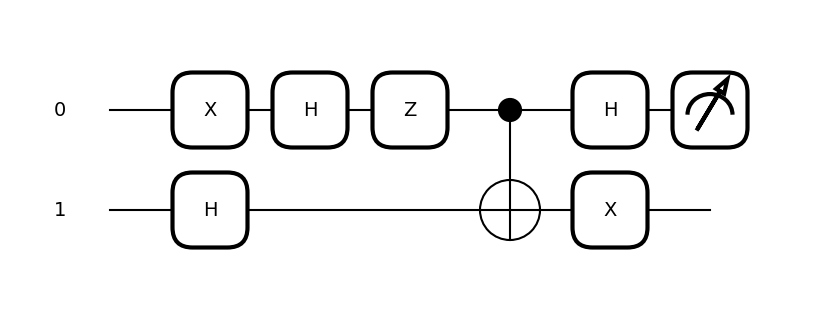

In [ ]:
#circuito
qml.draw_mpl(circuit)()
plt.show()

In [ ]:
#mostrar resultados
resultado1 = circuit()
print(resultado1)

0.9999999999999996


In [ ]:
#Circuito 2
@qml.qnode(dev1)
def circuit():
    qml.PauliX(wires=0) #Alocar a Porta Pauli X
    qml.PauliX(wires=1)
    qml.Barrier([0,1]) #Alocar a Barreira
    qml.Hadamard( wires = 0) #Alocar a Porta Hadamard
    qml.Hadamard( wires = 1)
    qml.Barrier([0,1])
    
    #ORACULOS
    qml.CNOT([0,1]) #Alocar a Porta CNOT
    
    qml.PauliX(wires=1)
    qml.Barrier([0,1])
    qml.Hadamard(wires=0)
    
    return qml.expval(qml.PauliZ(0)) # retornar o valor esperado de Pauli Z

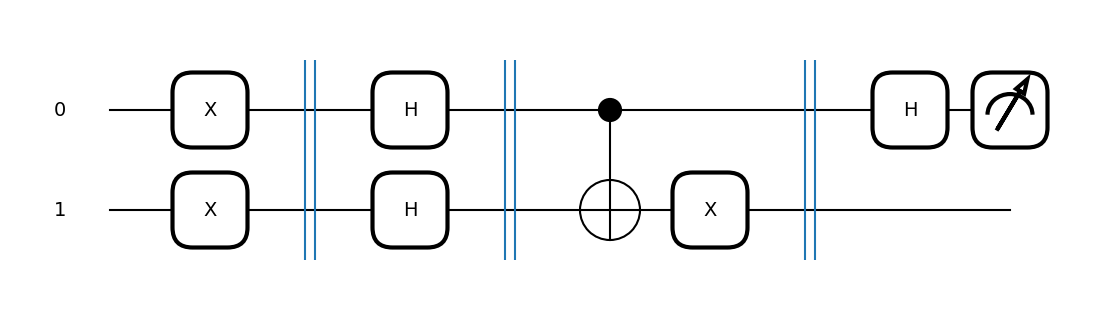

In [ ]:
#desenho circuito
qml.draw_mpl(circuit)()
plt.show()

In [ ]:
resultado = circuit()
print(resultado)

0.9999999999999996


In [ ]:
#Definir um novo circuito

dev3 = qml.device("default.qubit",wires=2)

In [ ]:
#Circuito 3
@qml.qnode(dev3)
def circuit():
    qml.PauliX(wires=0) #Alocar a Porta Pauli X
    qml.PauliX(wires=1)
    qml.Barrier([0,1])    #Alocar a Barreira
    qml.Hadamard( wires = 0)
    qml.Hadamard( wires = 1) #Alocar a Porta Hadamard
    qml.Barrier([0,1])
    
    #ORACULOS
    qml.PauliX(wires = 1)
    qml.Barrier([0,1])
    qml.Hadamard( wires = 0)
    
    
    return qml.expval(qml.PauliZ(0)) #retornar o valor esperado de Pauli Z

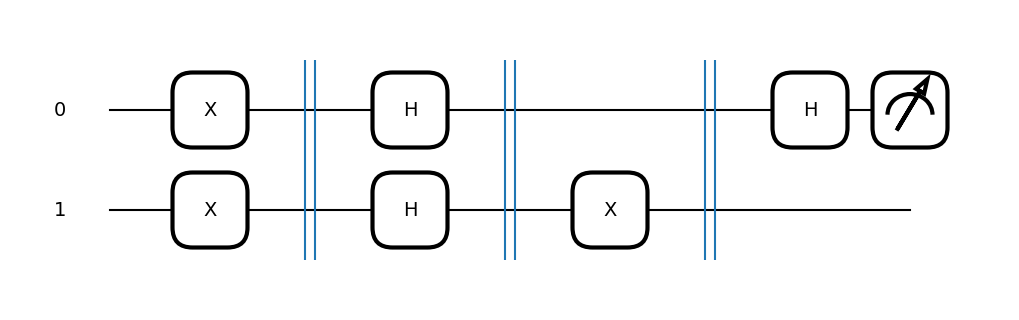

In [ ]:
#circuito impresso
qml.draw_mpl(circuit)()
plt.show()

In [ ]:
#Resultado
resultado = circuit()
print(resultado)

-0.9999999999999996
